In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [3]:
movies = pickle.load(open('movie_list.pkl', 'rb'))
similarity = pickle.load(open('similarity.pkl', 'rb'))
with open("svd_model.pkl", "rb") as f:
    svd_model = pickle.load(f)

ratings = pd.read_csv("ratings.csv")

In [4]:
def recommend_cb(movie, top_n=5):
    index = movies[movies['title'] == movie].index[0]
    distances = sorted(list(enumerate(similarity[index])), reverse=True, key=lambda x: x[1])
    return [movies.iloc[i[0]].title for i in distances[1:top_n+1]]


In [5]:
def recommend_svd(user_id, top_n=5):
    movie_ids = movies['movie_id'].values
    seen = ratings[ratings['userId'] == user_id]['movieId'].tolist()
    unseen = [m for m in movie_ids if m not in seen]
    predictions = [(mid, svd_model.predict(user_id, mid).est) for mid in unseen]
    top = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]
    return [movies[movies['movie_id'] == mid]['title'].values[0] for mid, _ in top]

In [6]:
def recommend_hybrid(user_id, movie, alpha=0.5, top_n=5):
    index = movies[movies['title'] == movie].index[0]
    movie_ids = movies['movie_id'].values
    sim_scores = similarity[index]
    predictions = [(i, svd_model.predict(user_id, movies.iloc[i].movie_id).est) for i in range(len(movies))]
    scores = [(i, alpha * sim_scores[i] + (1 - alpha) * pred) for i, (_, pred) in enumerate(predictions)]
    top = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    return [movies.iloc[i].title for i, _ in top]

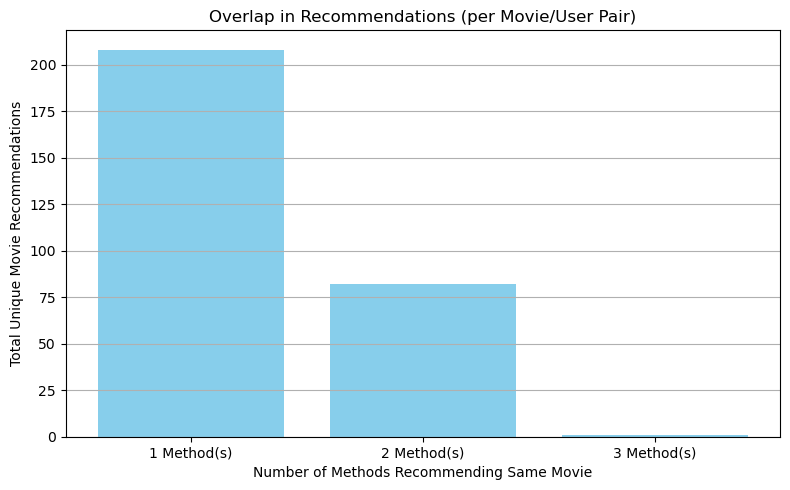

In [9]:
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

example_users = [1, 2, 3, 4, 5]
sample_movies = ["Inception", "The Dark Knight", "Interstellar", "The Matrix", "Avatar"]

# Stores how many methods recommended each movie per (user, selected_movie)
overlap_counter = Counter()

for user in example_users:
    for movie in sample_movies:
        cb = set(recommend_cb(movie))
        svd = set(recommend_svd(user))
        hyb = set(recommend_hybrid(user, movie))

        # Combine all recommendations
        all_recs = cb.union(svd).union(hyb)

        for m in all_recs:
            method_count = int(m in cb) + int(m in svd) + int(m in hyb)
            overlap_counter[method_count] += 1

# 📊 Prepare plot
labels = sorted(overlap_counter.keys())  # Should be [1, 2, 3]
values = [overlap_counter[k] for k in labels]

plt.figure(figsize=(8, 5))
plt.bar([f'{k} Method(s)' for k in labels], values, color='skyblue')
plt.title("Overlap in Recommendations (per Movie/User Pair)")
plt.xlabel("Number of Methods Recommending Same Movie")
plt.ylabel("Total Unique Movie Recommendations")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


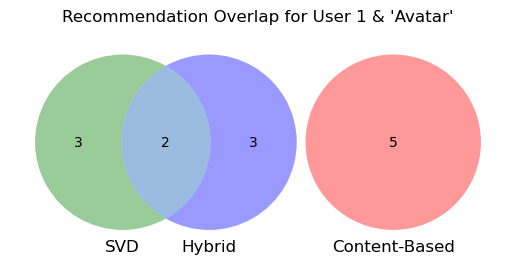

In [12]:
from matplotlib_venn import venn3

cb = set(recommend_cb("Avatar"))
svd = set(recommend_svd(1))
hyb = set(recommend_hybrid(1, "Avatar"))

venn3([cb, svd, hyb], set_labels=('Content-Based', 'SVD', 'Hybrid'))
plt.title("Recommendation Overlap for User 1 & 'Avatar'")
plt.show()


Jaccard Similarity between Models

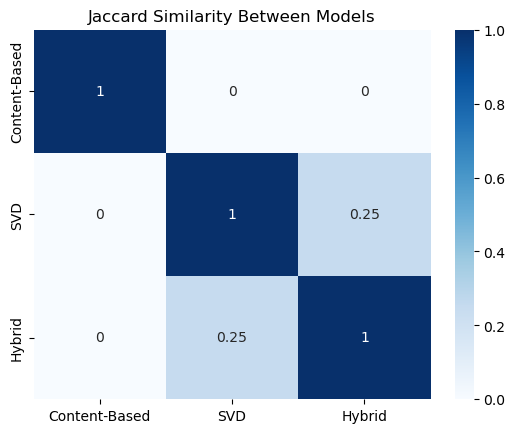

In [13]:
def jaccard(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

models = ['Content-Based', 'SVD', 'Hybrid']
matrix = []

for i, rec1 in enumerate([cb, svd, hyb]):
    row = []
    for rec2 in [cb, svd, hyb]:
        row.append(jaccard(rec1, rec2))
    matrix.append(row)

sns.heatmap(matrix, xticklabels=models, yticklabels=models, annot=True, cmap="Blues")
plt.title("Jaccard Similarity Between Models")
plt.show()
